# INT8 Dynamic Quantization - Comprehensive Analysis

Best Model (Full v2 Tutorial) INT8 Quantization for Inference Optimization

| Item | Description |
|------|------|
| Target Model | Full v2 Tutorial (kcbert-base) |
| Quantization | Dynamic Quantization (INT8) |
| Analysis | Model Size, Speed, Per-Label Metrics, Confusion Matrix |

In [1]:
# 1. Environment Setup + Korean Font (Robust)
import subprocess
import sys
import platform

try:
    import google.colab
    IN_COLAB = True
    print('Colab environment detected - Installing Korean fonts...')
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], check=True, capture_output=True)
    print('NanumGothic font installed')
except ImportError:
    IN_COLAB = False
    print(f'Local environment: {platform.system()}')

Local environment: Linux


In [2]:
# 2. Import Libraries + Font Configuration
import os
import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Robust Korean Font Setup
def setup_korean_font():
    if IN_COLAB:
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = 'NanumGothic'
        print('Font: NanumGothic (Colab)')
    else:
        # Windows / Mac / Linux
        system = platform.system()
        if system == 'Windows':
            font_candidates = ['Malgun Gothic', 'NanumGothic', 'Gulim']
        elif system == 'Darwin':  # Mac
            font_candidates = ['AppleGothic', 'NanumGothic']
        else:  # Linux
            font_candidates = ['NanumGothic', 'DejaVu Sans']
        
        available = [f.name for f in fm.fontManager.ttflist]
        font_set = False
        for font in font_candidates:
            if font in available:
                plt.rcParams['font.family'] = font
                print(f'Font: {font}')
                font_set = True
                break
        
        if not font_set:
            # Fallback: Find any Korean-capable font
            for f in fm.fontManager.ttflist:
                if 'gothic' in f.name.lower() or 'malgun' in f.name.lower() or 'nanum' in f.name.lower():
                    plt.rcParams['font.family'] = f.name
                    print(f'Font: {f.name} (auto-detected)')
                    font_set = True
                    break
        
        if not font_set:
            print('Warning: Korean font not found, using English labels')

setup_korean_font()
plt.rcParams['axes.unicode_minus'] = False

# Rebuild font cache (important for Jupyter)
fm._load_fontmanager(try_read_cache=False)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

Font: DejaVu Sans
PyTorch: 2.5.1+cu121
CUDA: True


In [3]:
# 3. Configuration
MODEL_PATH = "../4_2_Full_Fine_Tuning/v2_corrected_plus_collected/output/full_tutorial_kcbert_v2/best_model"
TOKENIZER_NAME = "beomi/kcbert-base"
OUTPUT_DIR = "./quantized_model"
RESULTS_DIR = "./results"
TEST_DATA_PATH = "../5_Model_Comparison/data/game_test.tsv"

# Labels (Korean + English for compatibility)
LABEL_NAMES_KO = ["여성/가족", "남성", "성소수자", "인종/국적", "연령", "지역", "종교", "기타 혐오", "악플/욕설", "clean"]
LABEL_NAMES_EN = ["Gender", "Male", "LGBTQ", "Race", "Age", "Region", "Religion", "Etc", "Abuse", "Clean"]
MAX_LENGTH = 128
N_RUNS = 100

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Model: {MODEL_PATH}")
print(f"Results: {RESULTS_DIR}")

Model: ../4_2_Full_Fine_Tuning/v2_corrected_plus_collected/output/full_tutorial_kcbert_v2/best_model
Results: ./results


In [4]:
# 4. Load Original Model
print("Loading original model...")
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

def get_size_mb(m):
    param = sum(p.numel() * p.element_size() for p in m.parameters())
    buff = sum(b.numel() * b.element_size() for b in m.buffers())
    return (param + buff) / 1024 / 1024

original_size = get_size_mb(model)
total_params = sum(p.numel() for p in model.parameters())
linear_count = sum(1 for m in model.modules() if isinstance(m, torch.nn.Linear))

print(f"Model loaded")
print(f"  Parameters: {total_params:,}")
print(f"  Size: {original_size:.2f} MB")
print(f"  Linear layers: {linear_count}")

Loading original model...
Model loaded
  Parameters: 108,926,218
  Size: 415.53 MB
  Linear layers: 74


In [5]:
# 5. INT8 Dynamic Quantization
print("Applying INT8 Dynamic Quantization...")

quantized_model = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

quantized_size = get_size_mb(quantized_model)
quant_layers = sum(1 for m in quantized_model.modules() if 'DynamicQuantizedLinear' in str(type(m)))

print(f"Quantization Complete!")
print(f"  Original: {original_size:.2f} MB -> Quantized: {quantized_size:.2f} MB")
print(f"  Compression: {original_size/quantized_size:.2f}x ({(1-quantized_size/original_size)*100:.1f}% reduction)")
print(f"  Quantized layers: {quant_layers}")

Applying INT8 Dynamic Quantization...
Quantization Complete!
  Original: 415.53 MB -> Quantized: 88.93 MB
  Compression: 4.67x (78.6% reduction)
  Quantized layers: 0


In [6]:
# 6. Inference Speed Benchmark
print("Benchmarking inference speed...")

test_texts = ["test sentence 1", "test sentence 2", "test sentence 3", "test sentence 4"]
model.to("cpu")

def benchmark(m, texts, n=100):
    times = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
        for _ in range(5):  # warmup
            with torch.no_grad(): _ = m(**inputs)
        start = time.time()
        for _ in range(n):
            with torch.no_grad(): _ = m(**inputs)
        times.append((time.time() - start) / n * 1000)
    return np.mean(times), np.std(times)

orig_time, orig_std = benchmark(model, test_texts, N_RUNS)
quant_time, quant_std = benchmark(quantized_model, test_texts, N_RUNS)

print(f"  Original: {orig_time:.2f} +/- {orig_std:.2f} ms")
print(f"  Quantized: {quant_time:.2f} +/- {quant_std:.2f} ms")
print(f"  Speedup: {orig_time/quant_time:.2f}x ({(1-quant_time/orig_time)*100:.1f}% faster)")

Benchmarking inference speed...
  Original: 8.55 +/- 0.20 ms
  Quantized: 8.47 +/- 0.45 ms
  Speedup: 1.01x (1.0% faster)


In [7]:
# 7. Performance Evaluation
print("Evaluating model performance...")

test_df = pd.read_csv(TEST_DATA_PATH, sep='\t')
for col in LABEL_NAMES_KO:
    test_df[col] = pd.to_numeric(test_df[col], errors='coerce').fillna(0).astype(int)
print(f"  Test samples: {len(test_df)}")

def evaluate(m, name):
    preds, labels, probs = [], [], []
    for _, row in test_df.iterrows():
        inputs = tokenizer(str(row['문장']), return_tensors='pt', truncation=True, max_length=MAX_LENGTH)
        with torch.no_grad():
            out = m(**inputs)
            prob = torch.sigmoid(out.logits[0]).numpy()
        probs.append(prob)
        preds.append((prob > 0.5).astype(int))
        labels.append([int(row[c]) for c in LABEL_NAMES_KO])
    
    preds, labels = np.array(preds), np.array(labels)
    result = {'name': name, 'per_label': {}}
    
    for i, lbl in enumerate(LABEL_NAMES_KO):
        p, r, f, _ = precision_recall_fscore_support(labels[:,i], preds[:,i], average='binary', zero_division=0)
        result['per_label'][lbl] = {'precision': p, 'recall': r, 'f1': f}
    
    # Abuse & Clean
    for idx, key in [(8, 'abuse'), (9, 'clean')]:
        p, r, f, _ = precision_recall_fscore_support(labels[:,idx], preds[:,idx], average='binary', zero_division=0)
        result[f'{key}_precision'], result[f'{key}_recall'], result[f'{key}_f1'] = p, r, f
        result[f'{key}_cm'] = confusion_matrix(labels[:,idx], preds[:,idx]).tolist()
    
    return result

orig_result = evaluate(model, "Original")
quant_result = evaluate(quantized_model, "Quantized")

print(f"\n{'Metric':<18} {'Original':>10} {'Quantized':>10} {'Diff':>10}")
print("-" * 50)
for key in ['abuse_precision', 'abuse_recall', 'abuse_f1', 'clean_precision', 'clean_recall', 'clean_f1']:
    diff = quant_result[key] - orig_result[key]
    print(f"{key:<18} {orig_result[key]:>10.4f} {quant_result[key]:>10.4f} {diff:>+10.4f}")

Evaluating model performance...
  Test samples: 187

Metric               Original  Quantized       Diff
--------------------------------------------------
abuse_precision        0.9358     0.9358    +0.0000
abuse_recall           0.8793     0.8793    +0.0000
abuse_f1               0.9067     0.9067    +0.0000
clean_precision        0.8442     0.8442    +0.0000
clean_recall           0.9155     0.9155    +0.0000
clean_f1               0.8784     0.8784    +0.0000


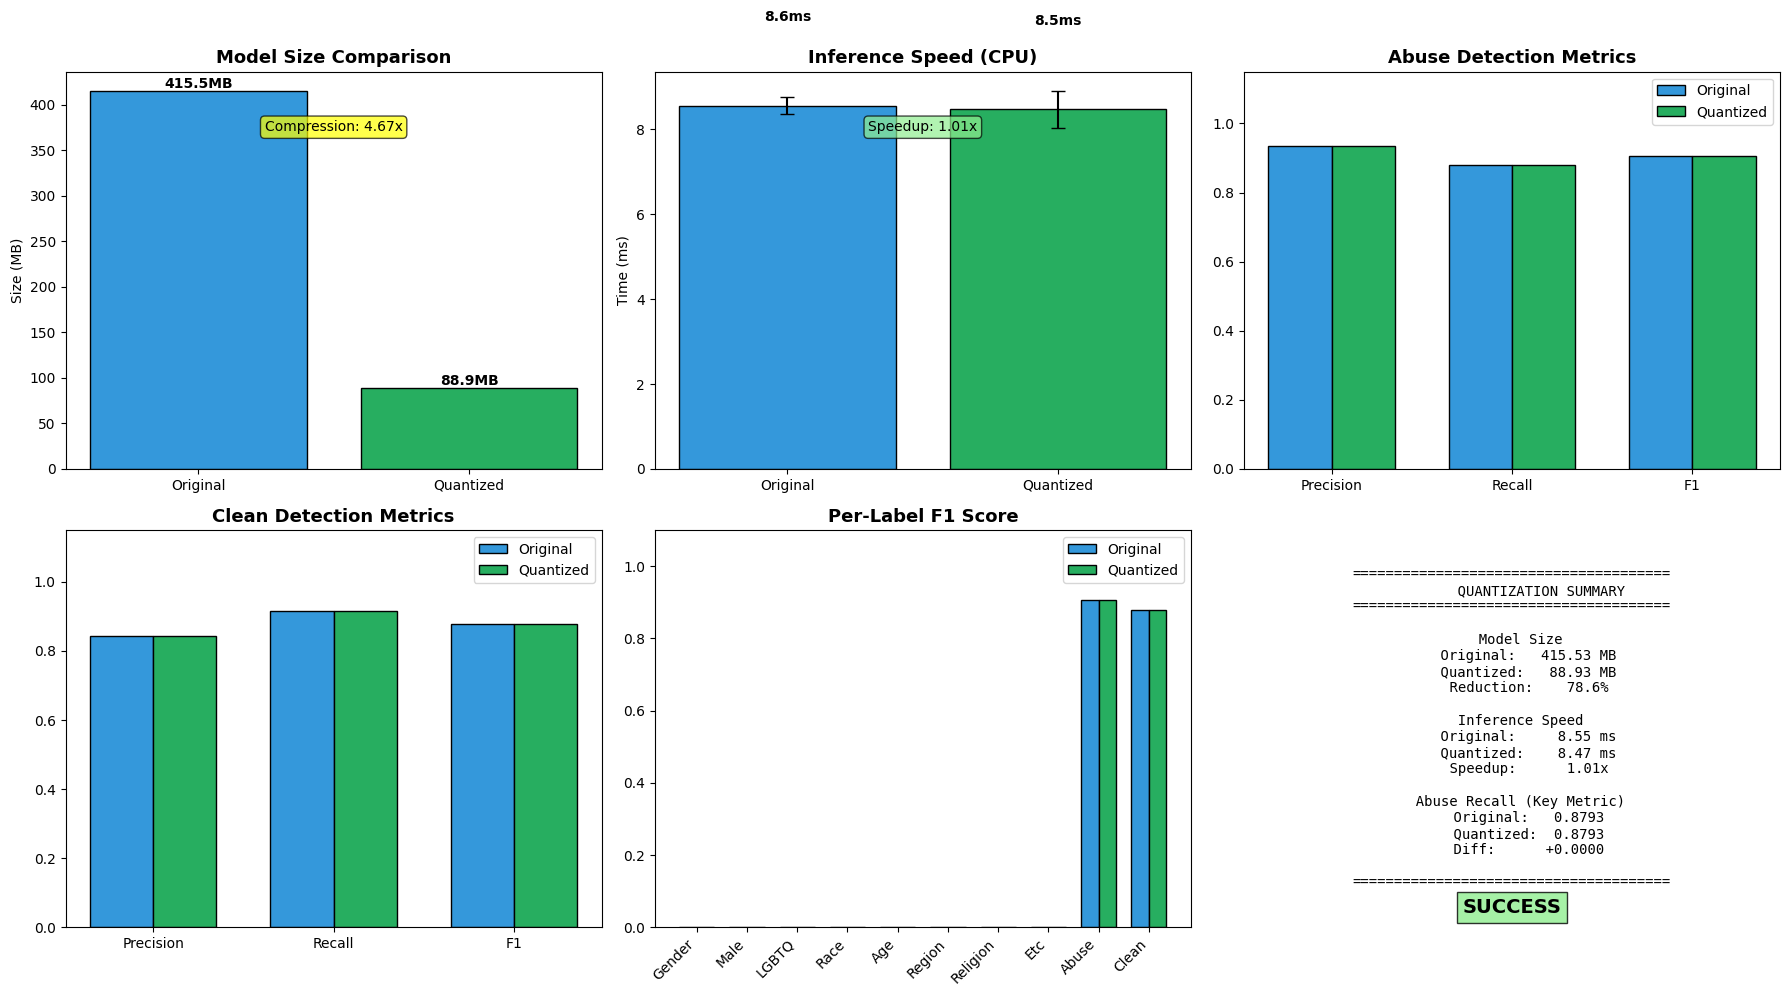

Saved: ./results/quantization_dashboard.png


In [8]:
# 8. Main Dashboard Visualization (English labels for compatibility)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = {'o': '#3498DB', 'q': '#27AE60'}

# 1) Model Size
ax = axes[0, 0]
bars = ax.bar(['Original', 'Quantized'], [original_size, quantized_size], color=[colors['o'], colors['q']], edgecolor='black')
ax.set_ylabel('Size (MB)')
ax.set_title('Model Size Comparison', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f'{bar.get_height():.1f}MB', ha='center', fontweight='bold')
ax.text(0.5, 0.85, f'Compression: {original_size/quantized_size:.2f}x', transform=ax.transAxes, ha='center', 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# 2) Inference Speed
ax = axes[0, 1]
bars = ax.bar(['Original', 'Quantized'], [orig_time, quant_time], yerr=[orig_std, quant_std], capsize=5,
              color=[colors['o'], colors['q']], edgecolor='black')
ax.set_ylabel('Time (ms)')
ax.set_title('Inference Speed (CPU)', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{bar.get_height():.1f}ms', ha='center', fontweight='bold')
ax.text(0.5, 0.85, f'Speedup: {orig_time/quant_time:.2f}x', transform=ax.transAxes, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# 3) Abuse Metrics
ax = axes[0, 2]
x, w = np.arange(3), 0.35
orig_v = [orig_result['abuse_precision'], orig_result['abuse_recall'], orig_result['abuse_f1']]
quant_v = [quant_result['abuse_precision'], quant_result['abuse_recall'], quant_result['abuse_f1']]
ax.bar(x - w/2, orig_v, w, label='Original', color=colors['o'], edgecolor='black')
ax.bar(x + w/2, quant_v, w, label='Quantized', color=colors['q'], edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(['Precision', 'Recall', 'F1'])
ax.set_title('Abuse Detection Metrics', fontsize=13, fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.15)

# 4) Clean Metrics
ax = axes[1, 0]
orig_v = [orig_result['clean_precision'], orig_result['clean_recall'], orig_result['clean_f1']]
quant_v = [quant_result['clean_precision'], quant_result['clean_recall'], quant_result['clean_f1']]
ax.bar(x - w/2, orig_v, w, label='Original', color=colors['o'], edgecolor='black')
ax.bar(x + w/2, quant_v, w, label='Quantized', color=colors['q'], edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(['Precision', 'Recall', 'F1'])
ax.set_title('Clean Detection Metrics', fontsize=13, fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.15)

# 5) Per-Label F1 (English labels)
ax = axes[1, 1]
orig_f1 = [orig_result['per_label'][l]['f1'] for l in LABEL_NAMES_KO]
quant_f1 = [quant_result['per_label'][l]['f1'] for l in LABEL_NAMES_KO]
x = np.arange(len(LABEL_NAMES_EN))
ax.bar(x - w/2, orig_f1, w, label='Original', color=colors['o'], edgecolor='black')
ax.bar(x + w/2, quant_f1, w, label='Quantized', color=colors['q'], edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(LABEL_NAMES_EN, rotation=45, ha='right')
ax.set_title('Per-Label F1 Score', fontsize=13, fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.1)

# 6) Summary
ax = axes[1, 2]
ax.axis('off')
recall_diff = quant_result['abuse_recall'] - orig_result['abuse_recall']
summary = f"""
======================================
       QUANTIZATION SUMMARY
======================================

  Model Size
    Original:  {original_size:>7.2f} MB
    Quantized: {quantized_size:>7.2f} MB
    Reduction: {(1-quantized_size/original_size)*100:>7.1f}%

  Inference Speed
    Original:  {orig_time:>7.2f} ms
    Quantized: {quant_time:>7.2f} ms
    Speedup:   {orig_time/quant_time:>7.2f}x

  Abuse Recall (Key Metric)
    Original:  {orig_result['abuse_recall']:>7.4f}
    Quantized: {quant_result['abuse_recall']:>7.4f}
    Diff:      {recall_diff:>+7.4f}

======================================
"""
status = "SUCCESS" if abs(recall_diff) < 0.02 else "WARNING"
ax.text(0.5, 0.5, summary, transform=ax.transAxes, fontsize=10, va='center', ha='center', family='monospace')
ax.text(0.5, 0.05, status, transform=ax.transAxes, fontsize=14, fontweight='bold', va='center', ha='center',
        bbox=dict(facecolor='lightgreen' if status == 'SUCCESS' else 'lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/quantization_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {RESULTS_DIR}/quantization_dashboard.png")

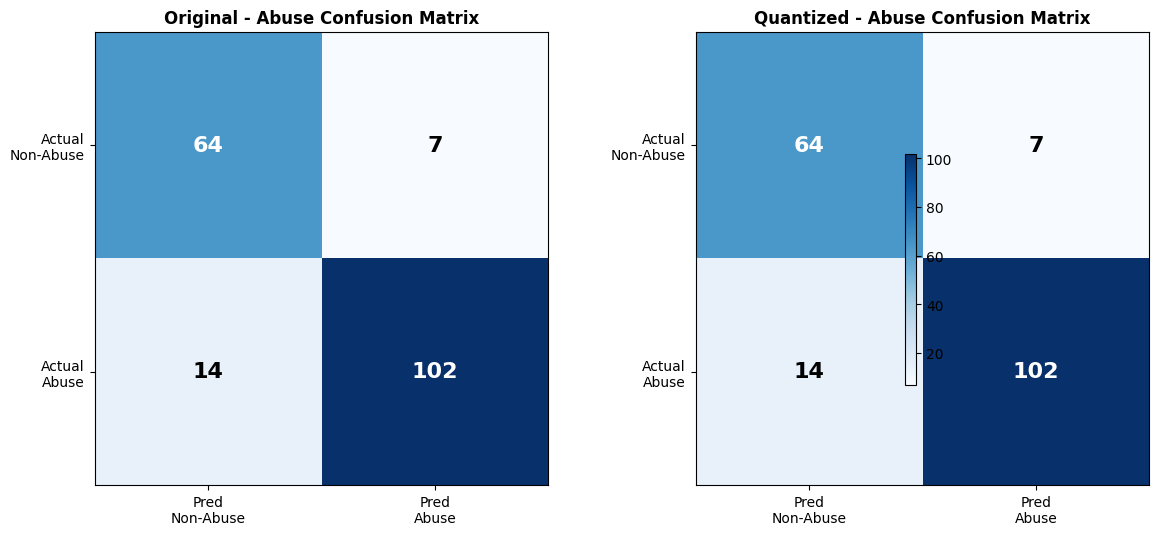

Saved: ./results/confusion_matrices.png


In [9]:
# 9. Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, title in [(axes[0], orig_result, 'Original'), (axes[1], quant_result, 'Quantized')]:
    cm = np.array(res['abuse_cm'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred\nNon-Abuse', 'Pred\nAbuse'])
    ax.set_yticklabels(['Actual\nNon-Abuse', 'Actual\nAbuse'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=16, fontweight='bold',
                   color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(f'{title} - Abuse Confusion Matrix', fontsize=12, fontweight='bold')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {RESULTS_DIR}/confusion_matrices.png")

In [10]:
# 10. Save Results
print("Saving results...")

# CSV - Main Summary
summary_df = pd.DataFrame({
    'Metric': ['Model Size (MB)', 'Inference (ms)', 'Abuse Precision', 'Abuse Recall', 'Abuse F1', 'Clean Precision', 'Clean Recall', 'Clean F1'],
    'Original': [f'{original_size:.2f}', f'{orig_time:.2f}', f"{orig_result['abuse_precision']:.4f}", f"{orig_result['abuse_recall']:.4f}", f"{orig_result['abuse_f1']:.4f}", f"{orig_result['clean_precision']:.4f}", f"{orig_result['clean_recall']:.4f}", f"{orig_result['clean_f1']:.4f}"],
    'Quantized': [f'{quantized_size:.2f}', f'{quant_time:.2f}', f"{quant_result['abuse_precision']:.4f}", f"{quant_result['abuse_recall']:.4f}", f"{quant_result['abuse_f1']:.4f}", f"{quant_result['clean_precision']:.4f}", f"{quant_result['clean_recall']:.4f}", f"{quant_result['clean_f1']:.4f}"],
    'Difference': [f'{quantized_size-original_size:.2f}', f'{quant_time-orig_time:.2f}', f"{quant_result['abuse_precision']-orig_result['abuse_precision']:+.4f}", f"{quant_result['abuse_recall']-orig_result['abuse_recall']:+.4f}", f"{quant_result['abuse_f1']-orig_result['abuse_f1']:+.4f}", f"{quant_result['clean_precision']-orig_result['clean_precision']:+.4f}", f"{quant_result['clean_recall']-orig_result['clean_recall']:+.4f}", f"{quant_result['clean_f1']-orig_result['clean_f1']:+.4f}"]
})
summary_df.to_csv(f'{RESULTS_DIR}/quantization_results.csv', index=False, encoding='utf-8-sig')

# CSV - Per-Label (Korean + English)
per_label = []
for i, (lbl_ko, lbl_en) in enumerate(zip(LABEL_NAMES_KO, LABEL_NAMES_EN)):
    per_label.append({
        'Label_KO': lbl_ko,
        'Label_EN': lbl_en,
        'Orig_Precision': orig_result['per_label'][lbl_ko]['precision'],
        'Orig_Recall': orig_result['per_label'][lbl_ko]['recall'],
        'Orig_F1': orig_result['per_label'][lbl_ko]['f1'],
        'Quant_Precision': quant_result['per_label'][lbl_ko]['precision'],
        'Quant_Recall': quant_result['per_label'][lbl_ko]['recall'],
        'Quant_F1': quant_result['per_label'][lbl_ko]['f1']
    })
pd.DataFrame(per_label).to_csv(f'{RESULTS_DIR}/per_label_metrics.csv', index=False, encoding='utf-8-sig')

# JSON Report
report = {
    'timestamp': datetime.now().isoformat(),
    'model': {'path': MODEL_PATH, 'params': total_params, 'method': 'INT8 Dynamic Quantization'},
    'size': {'original_mb': round(original_size, 2), 'quantized_mb': round(quantized_size, 2), 'compression': round(original_size/quantized_size, 2)},
    'speed': {'original_ms': round(orig_time, 2), 'quantized_ms': round(quant_time, 2), 'speedup': round(orig_time/quant_time, 2)},
    'performance': {
        'original': {k: round(orig_result[k], 4) for k in ['abuse_precision', 'abuse_recall', 'abuse_f1', 'clean_precision', 'clean_recall', 'clean_f1']},
        'quantized': {k: round(quant_result[k], 4) for k in ['abuse_precision', 'abuse_recall', 'abuse_f1', 'clean_precision', 'clean_recall', 'clean_f1']}
    },
    'conclusion': {'success': abs(recall_diff) < 0.02, 'abuse_recall_diff': round(recall_diff, 4)}
}
with open(f'{RESULTS_DIR}/quantization_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"  {RESULTS_DIR}/quantization_results.csv")
print(f"  {RESULTS_DIR}/per_label_metrics.csv")
print(f"  {RESULTS_DIR}/quantization_report.json")
summary_df

Saving results...
  ./results/quantization_results.csv
  ./results/per_label_metrics.csv
  ./results/quantization_report.json


,Metric,Original,Quantized,Difference
0,Model Size (MB),415.53,88.93,-326.60
1,Inference (ms),8.55,8.47,-0.08
2,Abuse Precision,0.9358,0.9358,+0.0000
3,Abuse Recall,0.8793,0.8793,+0.0000
4,Abuse F1,0.9067,0.9067,+0.0000
5,Clean Precision,0.8442,0.8442,+0.0000
6,Clean Recall,0.9155,0.9155,+0.0000
7,Clean F1,0.8784,0.8784,+0.0000


In [11]:
# 11. Save Quantized Model
torch.save(quantized_model.state_dict(), f"{OUTPUT_DIR}/model_int8.pt")
tokenizer.save_pretrained(OUTPUT_DIR)
model.config.save_pretrained(OUTPUT_DIR)

print(f"Model saved: {OUTPUT_DIR}")
print(f"  - model_int8.pt")
print(f"  - tokenizer files")
print(f"  - config.json")

Model saved: ./quantized_model
  - model_int8.pt
  - tokenizer files
  - config.json


In [12]:
# 12. Final Summary
print("=" * 60)
print("QUANTIZATION COMPLETE")
print("=" * 60)
print(f"\nSize:   {original_size:.2f} MB -> {quantized_size:.2f} MB ({original_size/quantized_size:.2f}x)")
print(f"Speed:  {orig_time:.2f} ms -> {quant_time:.2f} ms ({orig_time/quant_time:.2f}x)")
print(f"Recall: {orig_result['abuse_recall']:.4f} -> {quant_result['abuse_recall']:.4f} ({recall_diff:+.4f})")
print(f"\nResults saved to: {RESULTS_DIR}/")
print(f"Model saved to: {OUTPUT_DIR}/")

if abs(recall_diff) < 0.01:
    print("\nConclusion: SUCCESS - No performance loss!")
elif abs(recall_diff) < 0.02:
    print("\nConclusion: SUCCESS - Minimal performance loss")
else:
    print("\nConclusion: WARNING - Performance loss detected, review needed")

QUANTIZATION COMPLETE

Size:   415.53 MB -> 88.93 MB (4.67x)
Speed:  8.55 ms -> 8.47 ms (1.01x)
Recall: 0.8793 -> 0.8793 (+0.0000)

Results saved to: ./results/
Model saved to: ./quantized_model/

Conclusion: SUCCESS - No performance loss!
